In [64]:
%%capture
!pip install  scikit-learn tensorflow
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [65]:
# Descargar datos
df = yf.download("RB=F", period="10y", interval="1d")

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RB=F,RB=F,RB=F,RB=F,RB=F
Date,,,,,
2016-04-06,1.3947,1.4089,1.3582,1.3831,60415
2016-04-07,1.3812,1.4106,1.3613,1.3956,58562
2016-04-08,1.4637,1.4666,1.3812,1.3888,67709
2016-04-11,1.5077,1.5114,1.4507,1.4636,60456
2016-04-12,1.5343,1.5386,1.4932,1.5023,58656


In [66]:
df = df.rename(columns={
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Volume": "volume"
})

df = df.dropna()

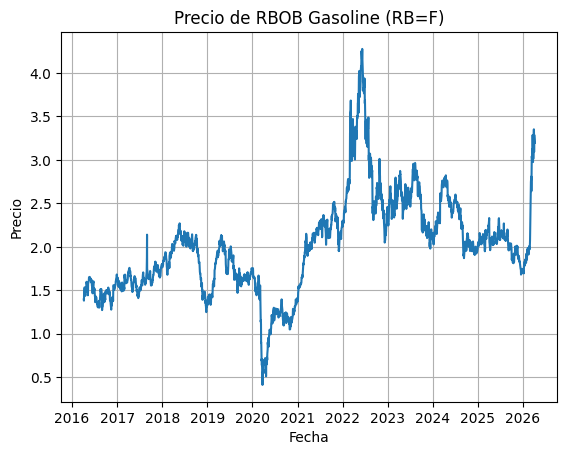

In [67]:
plt.figure()
plt.plot(df.index, df["close"])
plt.title("Precio de RBOB Gasoline (RB=F)")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.grid()

plt.show()

## Modelo FFNN

In [68]:
# Usamos solo el precio de cierre
serie_tiempo = df['close'].dropna().values.reshape(-1, 1)

In [69]:
# Seleccionamos train y test (80/20)
train_size = int(len(serie_tiempo) * 0.8)
train_data = serie_tiempo[:train_size]
test_data = serie_tiempo[train_size:]

In [70]:
# Iniciamos el escalador
scaler = MinMaxScaler(feature_range=(0, 1))

# Aplicamos el escalador SOLO a los datos de entrenamiento
train_scaled = scaler.fit_transform(train_data)

# Ahora escalador con parametros del train, pero para transformar los datos de test
test_scaled = scaler.transform(test_data)

In [71]:
# Función para crear ventanas deslizantes
def crear_ventanas(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

# SELECCIÓN DE TAMAÑO DE VENTANA
window_size = 10
X_train, y_train = crear_ventanas(train_scaled, window_size)
X_test, y_test = crear_ventanas(test_scaled, window_size)

In [72]:
# Iniciamos el modelo FFNN
model = Sequential([
    # Capa 1: input_dim DEBE coincidir con el window_size
    Dense(16, activation='relu', input_dim=window_size, name='Capa_Oculta_1'),

    # Capa 2: Extracción de características no lineales
    Dense(8, activation='relu', name='Capa_Oculta_2'),

    # Capa de Salida: 1 neurona Funcion de act LINEAL
    Dense(1, name='Salida_Pronostico')
])
model.summary()

# Usamos el optimizador Adam y MSE
optimizador = Adam(learning_rate=0.005)
model.compile(optimizer=optimizador, loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=60,           # Cantidad de veces que verá el dataset completo
    batch_size=8,        # Actualiza los pesos cada 8 ventanas
    validation_data=(X_test, y_test), # Evaluamos en datos que no ha visto
    verbose=0            # 0 para no mostrar info
)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Oculta_1 (Dense)           │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_2 (Dense)           │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida_Pronostico (Dense)       │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
# Predicciones
preds = model.predict(X_test)

# Asegurar formato 2D
preds = preds.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Desescalar
preds = scaler.inverse_transform(preds)
y_test_real = scaler.inverse_transform(y_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


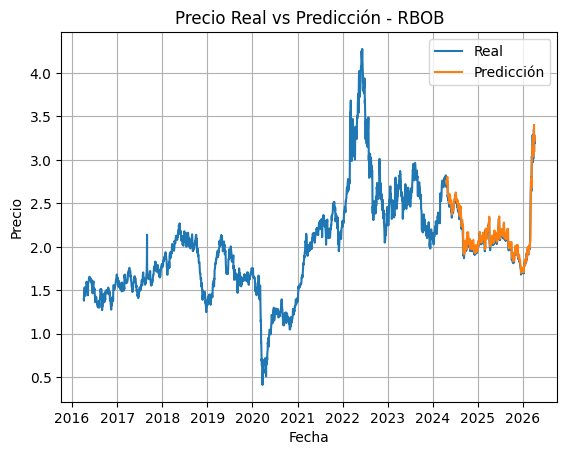

In [74]:
# Crear serie completa para comparar
df_plot = df.copy()

# Crear columna de predicciones vacía
df_plot["pred"] = None

# Insertar predicciones en el tramo de test
df_plot.iloc[-len(preds):, df_plot.columns.get_loc("pred")] = preds.flatten()

# Graficar
plt.figure()

plt.plot(df_plot.index, df_plot["close"], label="Real")
plt.plot(df_plot.index, df_plot["pred"], label="Predicción")

plt.title("Precio Real vs Predicción - RBOB")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid()

plt.show()

In [77]:
# Métricas
mae = mean_absolute_error(y_test_real, preds)
rmse = np.sqrt(mean_squared_error(y_test_real, preds))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE: 0.039
RMSE: 0.055


In [75]:
import numpy as np

real = np.sign(np.diff(y_test_real.flatten()))
pred = np.sign(np.diff(preds.flatten()))

DA = np.mean(real == pred)

print("Directional Accuracy:", DA)

Directional Accuracy: 0.4878048780487805
